In [219]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.special import j1

In [220]:
lambd = 3.5 / 100         
l = 23.7 / 100      
h = 12.0 / 100       
er = 2.2                  
tgd = 2e-4                
d_avg = 2.3 / 100
d_max = 2.9 / 100
c = 3e8
vf = c / (1 + lambd / 21)
e = c / vf

In [221]:
def lambda_1(x):
    return np.where(x == 0, 1.0, (2 * j1(x)) / x)

In [222]:
steps = []
F1h = []
F1e = []
FC = []
FH = []
FE = []
FH2 = []
FE2 = []

for teta in np.arange(0.01, np.pi / 2, 0.00001):
    fb = (e - 1) / np.sin(((np.pi * l) / lambd) * (e - 1)) * np.sin(((np.pi * l) / lambd) * (e - np.cos(teta))) / (e - np.cos(teta))

    f1h = lambda_1((np.pi * d_avg) / lambd * np.sin(teta))
    f1e = lambda_1((np.pi * d_avg) / lambd * np.sin(teta)) * np.cos(teta)

    fc = np.cos((np.pi * h / lambd) * np.sin(teta))
    fh = f1h * fc * fb
    fe = f1e * fc * fb

    fh2 = fb * np.cos((np.pi * h / lambd) * np.sin(teta))
    fe2 = fb * np.cos((np.pi * h / lambd) * np.sin(teta)) * np.cos(teta)

    F1h.append(f1h)
    F1e.append(f1e)
    FC.append(fc)
    FH.append(fh)
    FE.append(fe)
    FH2.append(fh2)
    FE2.append(fe2)

    steps.append(math.degrees(teta))

In [223]:
max_x_FH = []
max_y_FH = []
min_x_FH = []
min_y_FH = []

for i in range(1, len(FH) - 1):
    if FH[i] > FH[i - 1] and FH[i] > FH[i + 1]:
        max_x_FH.append(steps[i])
        max_y_FH.append(FH[i])

for i in range(1, len(FH) - 1):
    if FH[i] > 0 and FH[i + 1] < 0 or FH[i] < 0 and FH[i + 1] > 0:
        min_x_FH.append(steps[i])
        min_y_FH.append(0)

In [224]:
max_x_FE = []
max_y_FE = []
min_x_FE = []
min_y_FE = []

for i in range(1, len(FE) - 1):
    if FE[i] > FE[i - 1] and FE[i] > FE[i + 1]:
        max_x_FE.append(steps[i])
        max_y_FE.append(FE[i])

for i in range(1, len(FE) - 1):
    if FE[i] > 0 and FE[i + 1] < 0 or FE[i] < 0 and FE[i + 1] > 0:
        min_x_FE.append(steps[i])
        min_y_FE.append(0)

In [225]:
max_x_FH2 = []
max_y_FH2 = []
min_x_FH2 = []
min_y_FH2 = []

for i in range(1, len(FH2) - 1):
    if FH2[i] > FH2[i - 1] and FH2[i] > FH2[i + 1]:
        max_x_FH2.append(steps[i])
        max_y_FH2.append(FH2[i])

for i in range(1, len(FH2) - 1):
    if FH2[i] > 0 and FH2[i + 1] < 0 or FH2[i] < 0 and FH2[i + 1] > 0:
        min_x_FH2.append(steps[i])
        min_y_FH2.append(0)

In [226]:
max_x_FE2 = []
max_y_FE2 = []
min_x_FE2 = []
min_y_FE2 = []

for i in range(1, len(FE2) - 1):
    if FE2[i] > FE2[i - 1] and FE2[i] > FE2[i + 1]:
        max_x_FE2.append(steps[i])
        max_y_FE2.append(FE2[i])

for i in range(1, len(FE2) - 1):
    if FE2[i] > 0 and FE2[i + 1] < 0 or FE2[i] < 0 and FE2[i + 1] > 0:
        min_x_FE2.append(steps[i])
        min_y_FE2.append(0)

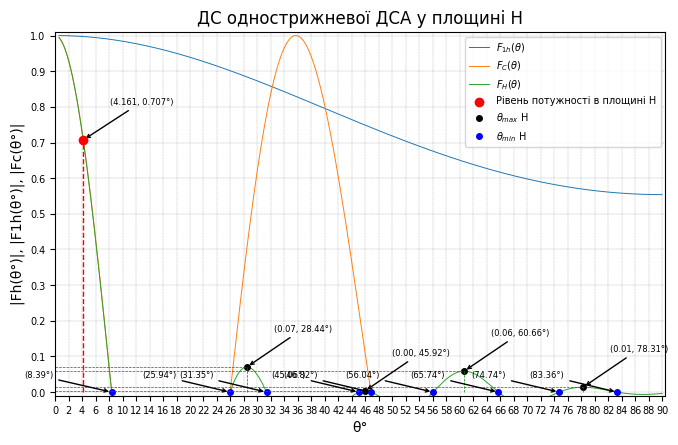

In [227]:
for index, f in enumerate(FH):
    if 0.707 < f < 0.708:
        y707 = f
        x707 = steps[index]
fig, ax = plt.subplots(figsize=(20/2.54, 12/2.54))
plt.title(f"ДС однострижневої ДСА у площині H")
ax.plot(steps, F1h, linewidth=0.7, label="$ F_{1h}(θ) $")
ax.plot(steps, FC, linewidth=0.7, label="$ F_{C}(θ) $")
ax.plot(steps, FH, linewidth=0.7, label="$ F_{H}(θ) $")

plt.vlines(x=x707, ymin=0, ymax=y707, colors='red', linestyles='dashed', linewidth=1)
plt.scatter(x707, y707, color='red', zorder=5, label="Рівень потужності в площині H")

plt.annotate(f'({x707:.3f}, {y707:.3f}\u00b0)',
                 xy=(x707, y707),
                 xytext=(x707+4, y707+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

ax.plot(max_x_FH, max_y_FH, "o", markersize=4, color="black", label="$ \\theta_{max} $ H")
ax.plot(min_x_FH, min_y_FH, "o", markersize=4, color="blue", label="$ \\theta_{min} $ H")

ax.set_xlabel('θ' + '\u00b0', fontsize=10)
ax.set_ylabel('|Fh(θ' + '\u00b0' + ')|, |F1h(θ' + '\u00b0' + ')|, |Fc(θ' + '\u00b0' + ')|', fontsize=10)
plt.xticks(np.arange(0, 100, 2), fontsize=7)
plt.yticks(np.arange(0, 1.2, 0.1), fontsize=7)
plt.ylim(-0.01, 1.01)
plt.xlim(0, 90.5)


for i in range(len(max_x_FH)):
    plt.vlines(x=max_x_FH[i], ymin=0, ymax=max_y_FH[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.hlines(y=max_y_FH[i], xmin=0, xmax=max_x_FH[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.annotate(f'({max_y_FH[i]:.2f}, {max_x_FH[i]:.2f}\u00b0)',
                 xy=(max_x_FH[i], max_y_FH[i]),
                 xytext=(max_x_FH[i]+4, max_y_FH[i]+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
for i in range(len(min_x_FH)):
    plt.annotate(f'({min_x_FH[i]:.2f}\u00b0)',
                 xy=(min_x_FH[i], min_y_FH[i]),
                 xytext=(min_x_FH[i]-13, min_y_FH[i]+0.04),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

plt.legend(loc="upper right", fontsize=7)
plt.grid(which='both', linestyle='--', linewidth=0.2, color='gray')

fig.savefig("ДС однострижневої ДСА у площині H, лабораторна 4.jpg", dpi=600)
plt.show()

In [228]:
print("Ширина головної пелюстки = " + str(round(x707 * 2, 2)) + '\u00b0')

Ширина головної пелюстки = 8.32°


In [229]:
print("Табл. 1 - Значення нульових кутів")
print("-----------------")
print("| № |  θ  |FH(θ)|")
m = 1
for i in min_x_FH:
    print(f"| {m} |{i:.2f}|  {0}  |")
    m += 1
print("-----------------")

print("Табл. 2 - Значення максимальних кутів")
print("-----------------")
print("| № |  θ  |FH(θ)|")
m = 1
for i in max_x_FH:
    print(f"| {m} |{i:.2f}| {max_y_FH[m-1]:.2f}|")
    m += 1
print("-----------------")

Табл. 1 - Значення нульових кутів
-----------------
| № |  θ  |FH(θ)|
| 1 |8.39|  0  |
| 2 |25.94|  0  |
| 3 |31.35|  0  |
| 4 |45.06|  0  |
| 5 |46.82|  0  |
| 6 |56.04|  0  |
| 7 |65.74|  0  |
| 8 |74.74|  0  |
| 9 |83.36|  0  |
-----------------
Табл. 2 - Значення максимальних кутів
-----------------
| № |  θ  |FH(θ)|
| 1 |28.44| 0.07|
| 2 |45.92| 0.00|
| 3 |60.66| 0.06|
| 4 |78.31| 0.01|
-----------------


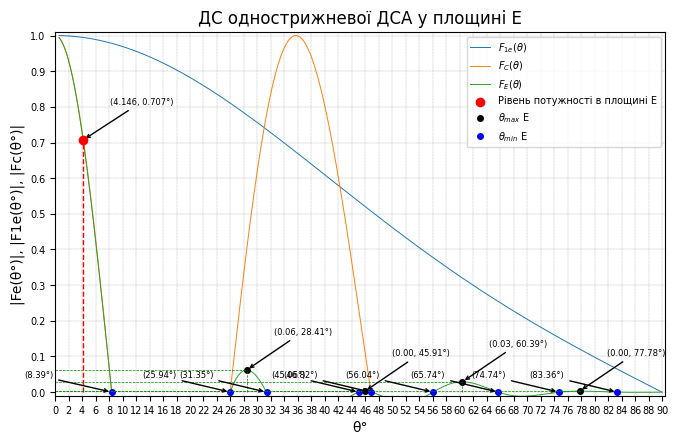

In [230]:
for index, f in enumerate(FE):
    if 0.707 < f < 0.708:
        y707 = f
        x707 = steps[index]

fig, ax = plt.subplots(figsize=(20/2.54, 12/2.54))
plt.title(f"ДС однострижневої ДСА у площині E")
ax.plot(steps, F1e, linewidth=0.7, label="$ F_{1e}(θ) $")
ax.plot(steps, FC, linewidth=0.7, label="$ F_{C}(θ) $")
ax.plot(steps, FE, linewidth=0.7, label="$ F_{E}(θ) $")

plt.vlines(x=x707, ymin=0, ymax=y707, colors='red', linestyles='dashed', linewidth=1)
plt.scatter(x707, y707, color='red', zorder=5, label="Рівень потужності в площині E")

plt.annotate(f'({x707:.3f}, {y707:.3f}\u00b0)',
                 xy=(x707, y707),
                 xytext=(x707+4, y707+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

ax.plot(max_x_FE, max_y_FE, "o", markersize=4, color="black", label="$ \\theta_{max} $ E")
ax.plot(min_x_FE, min_y_FE, "o", markersize=4, color="blue", label="$ \\theta_{min} $ E")

ax.set_xlabel('θ' + '\u00b0', fontsize=10)
ax.set_ylabel('|Fe(θ' + '\u00b0' + ')|, |F1e(θ' + '\u00b0' + ')|, |Fc(θ' + '\u00b0' + ')|', fontsize=10)
plt.xticks(np.arange(0, 100, 2), fontsize=7)
plt.yticks(np.arange(0, 1.2, 0.1), fontsize=7)
plt.ylim(-0.01, 1.01)
plt.xlim(0, 90.5)


for i in range(len(max_x_FE)):
    plt.vlines(x=max_x_FE[i], ymin=0, ymax=max_y_FE[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.hlines(y=max_y_FE[i], xmin=0, xmax=max_x_FE[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.annotate(f'({max_y_FE[i]:.2f}, {max_x_FE[i]:.2f}\u00b0)',
                 xy=(max_x_FE[i], max_y_FE[i]),
                 xytext=(max_x_FE[i]+4, max_y_FE[i]+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
for i in range(len(min_x_FE)):
    plt.annotate(f'({min_x_FE[i]:.2f}\u00b0)',
                 xy=(min_x_FE[i], min_y_FE[i]),
                 xytext=(min_x_FE[i]-13, min_y_FE[i]+0.04),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

plt.legend(loc="upper right", fontsize=7)
plt.grid(which='both', linestyle='--', linewidth=0.2, color='gray')

fig.savefig("ДС однострижневої ДСА у площині E, лабораторна 4.jpg", dpi=600)
plt.show()

In [231]:
print("Ширина головної пелюстки = " + str(round(x707 * 2, 2)) + '\u00b0')

Ширина головної пелюстки = 8.29°


In [232]:
print("Табл. 1 - Значення нульових кутів")
print("-----------------")
print("| № |  θ  |FE(θ)|")
m = 1
for i in min_x_FE:
    print(f"| {m} |{i:.2f}|  {0}  |")
    m += 1
print("-----------------")

print("Табл. 2 - Значення максимальних кутів")
print("-----------------")
print("| № |  θ  |FE(θ)|")
m = 1
for i in max_x_FE:
    print(f"| {m} |{i:.2f}| {max_y_FE[m-1]:.2f}|")
    m += 1
print("-----------------")

Табл. 1 - Значення нульових кутів
-----------------
| № |  θ  |FE(θ)|
| 1 |8.39|  0  |
| 2 |25.94|  0  |
| 3 |31.35|  0  |
| 4 |45.06|  0  |
| 5 |46.82|  0  |
| 6 |56.04|  0  |
| 7 |65.74|  0  |
| 8 |74.74|  0  |
| 9 |83.36|  0  |
-----------------
Табл. 2 - Значення максимальних кутів
-----------------
| № |  θ  |FE(θ)|
| 1 |28.41| 0.06|
| 2 |45.91| 0.00|
| 3 |60.39| 0.03|
| 4 |77.78| 0.00|
-----------------


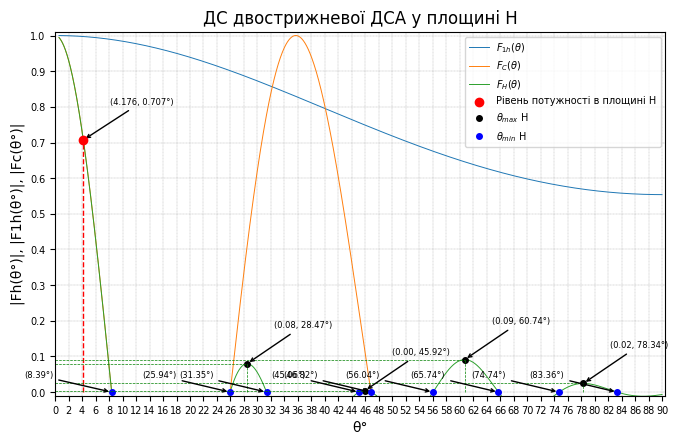

In [233]:
for index, f in enumerate(FH2):
    if 0.707 < f < 0.708:
        y707 = f
        x707 = steps[index]

fig, ax = plt.subplots(figsize=(20/2.54, 12/2.54))
plt.title(f"ДС двострижневої ДСА у площині H")
ax.plot(steps, F1h, linewidth=0.7, label="$ F_{1h}(θ) $")
ax.plot(steps, FC, linewidth=0.7, label="$ F_{C}(θ) $")
ax.plot(steps, FH2, linewidth=0.7, label="$ F_{H}(θ) $")

plt.vlines(x=x707, ymin=0, ymax=y707, colors='red', linestyles='dashed', linewidth=1)
plt.scatter(x707, y707, color='red', zorder=5, label="Рівень потужності в площині H")

plt.annotate(f'({x707:.3f}, {y707:.3f}\u00b0)',
                 xy=(x707, y707),
                 xytext=(x707+4, y707+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

ax.plot(max_x_FH2, max_y_FH2, "o", markersize=4, color="black", label="$ \\theta_{max} $ H")
ax.plot(min_x_FH2, min_y_FH2, "o", markersize=4, color="blue", label="$ \\theta_{min} $ H")

ax.set_xlabel('θ' + '\u00b0', fontsize=10)
ax.set_ylabel('|Fh(θ' + '\u00b0' + ')|, |F1h(θ' + '\u00b0' + ')|, |Fc(θ' + '\u00b0' + ')|', fontsize=10)
plt.xticks(np.arange(0, 100, 2), fontsize=7)
plt.yticks(np.arange(0, 1.2, 0.1), fontsize=7)
plt.ylim(-0.01, 1.01)
plt.xlim(0, 90.5)


for i in range(len(max_x_FH2)):
    plt.vlines(x=max_x_FH2[i], ymin=0, ymax=max_y_FH2[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.hlines(y=max_y_FH2[i], xmin=0, xmax=max_x_FH2[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.annotate(f'({max_y_FH2[i]:.2f}, {max_x_FH2[i]:.2f}\u00b0)',
                 xy=(max_x_FH2[i], max_y_FH2[i]),
                 xytext=(max_x_FH2[i]+4, max_y_FH2[i]+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
for i in range(len(min_x_FH2)):
    plt.annotate(f'({min_x_FH2[i]:.2f}\u00b0)',
                 xy=(min_x_FH2[i], min_y_FH2[i]),
                 xytext=(min_x_FH2[i]-13, min_y_FH2[i]+0.04),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

plt.legend(loc="upper right", fontsize=7)
plt.grid(which='both', linestyle='--', linewidth=0.2, color='gray')

fig.savefig("ДС двострижневої ДСА у площині H, лабораторна 4.jpg", dpi=600)
plt.show()

In [234]:
print("Ширина головної пелюстки = " + str(round(x707 * 2, 2)) + '\u00b0')

Ширина головної пелюстки = 8.35°


In [235]:
print("Табл. 1 - Значення нульових кутів")
print("-----------------")
print("| № |  θ  |FE(θ)|")
m = 1
for i in min_x_FH2:
    print(f"| {m} |{i:.2f}|  {0}  |")
    m += 1
print("-----------------")

print("Табл. 2 - Значення максимальних кутів")
print("-----------------")
print("| № |  θ  |FE(θ)|")
m = 1
for i in max_x_FH2:
    print(f"| {m} |{i:.2f}| {max_y_FH2[m-1]:.2f}|")
    m += 1
print("-----------------")

Табл. 1 - Значення нульових кутів
-----------------
| № |  θ  |FE(θ)|
| 1 |8.39|  0  |
| 2 |25.94|  0  |
| 3 |31.35|  0  |
| 4 |45.06|  0  |
| 5 |46.82|  0  |
| 6 |56.04|  0  |
| 7 |65.74|  0  |
| 8 |74.74|  0  |
| 9 |83.36|  0  |
-----------------
Табл. 2 - Значення максимальних кутів
-----------------
| № |  θ  |FE(θ)|
| 1 |28.47| 0.08|
| 2 |45.92| 0.00|
| 3 |60.74| 0.09|
| 4 |78.34| 0.02|
-----------------


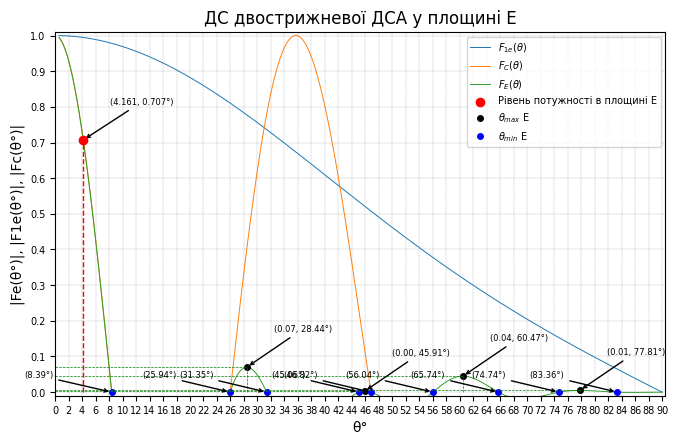

In [236]:
for index, f in enumerate(FE2):
    if 0.707 < f < 0.708:
        y707 = f
        x707 = steps[index]

fig, ax = plt.subplots(figsize=(20/2.54, 12/2.54))
plt.title(f"ДС двострижневої ДСА у площині E")
ax.plot(steps, F1e, linewidth=0.7, label="$ F_{1e}(θ) $")
ax.plot(steps, FC, linewidth=0.7, label="$ F_{C}(θ) $")
ax.plot(steps, FE2, linewidth=0.7, label="$ F_{E}(θ) $")

plt.vlines(x=x707, ymin=0, ymax=y707, colors='red', linestyles='dashed', linewidth=1)
plt.scatter(x707, y707, color='red', zorder=5, label="Рівень потужності в площині E")

plt.annotate(f'({x707:.3f}, {y707:.3f}\u00b0)',
                 xy=(x707, y707),
                 xytext=(x707+4, y707+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

ax.plot(max_x_FE2, max_y_FE2, "o", markersize=4, color="black", label="$ \\theta_{max} $ E")
ax.plot(min_x_FE2, min_y_FE2, "o", markersize=4, color="blue", label="$ \\theta_{min} $ E")

ax.set_xlabel('θ' + '\u00b0', fontsize=10)
ax.set_ylabel('|Fe(θ' + '\u00b0' + ')|, |F1e(θ' + '\u00b0' + ')|, |Fc(θ' + '\u00b0' + ')|', fontsize=10)
plt.xticks(np.arange(0, 100, 2), fontsize=7)
plt.yticks(np.arange(0, 1.2, 0.1), fontsize=7)
plt.ylim(-0.01, 1.01)
plt.xlim(0, 90.5)


for i in range(len(max_x_FE2)):
    plt.vlines(x=max_x_FE2[i], ymin=0, ymax=max_y_FE2[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.hlines(y=max_y_FE2[i], xmin=0, xmax=max_x_FE2[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.annotate(f'({max_y_FE2[i]:.2f}, {max_x_FE2[i]:.2f}\u00b0)',
                 xy=(max_x_FE2[i], max_y_FE2[i]),
                 xytext=(max_x_FE2[i]+4, max_y_FE2[i]+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
for i in range(len(min_x_FE2)):
    plt.annotate(f'({min_x_FE2[i]:.2f}\u00b0)',
                 xy=(min_x_FE2[i], min_y_FE2[i]),
                 xytext=(min_x_FE2[i]-13, min_y_FE2[i]+0.04),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

plt.legend(loc="upper right", fontsize=7)
plt.grid(which='both', linestyle='--', linewidth=0.2, color='gray')

fig.savefig("ДС двострижневої ДСА у площині E, лабораторна 4.jpg", dpi=600)
plt.show()

In [237]:
print("Ширина головної пелюстки = " + str(round(x707 * 2, 2)) + '\u00b0')

Ширина головної пелюстки = 8.32°


In [238]:
print("Табл. 1 - Значення нульових кутів")
print("-----------------")
print("| № |  θ  |FE(θ)|")
m = 1
for i in min_x_FE2:
    print(f"| {m} |{i:.2f}|  {0}  |")
    m += 1
print("-----------------")

print("Табл. 2 - Значення максимальних кутів")
print("-----------------")
print("| № |  θ  |FE(θ)|")
m = 1
for i in max_x_FE2:
    print(f"| {m} |{i:.2f}| {max_y_FE2[m-1]:.2f}|")
    m += 1
print("-----------------")

Табл. 1 - Значення нульових кутів
-----------------
| № |  θ  |FE(θ)|
| 1 |8.39|  0  |
| 2 |25.94|  0  |
| 3 |31.35|  0  |
| 4 |45.06|  0  |
| 5 |46.82|  0  |
| 6 |56.04|  0  |
| 7 |65.74|  0  |
| 8 |74.74|  0  |
| 9 |83.36|  0  |
-----------------
Табл. 2 - Значення максимальних кутів
-----------------
| № |  θ  |FE(θ)|
| 1 |28.44| 0.07|
| 2 |45.91| 0.00|
| 3 |60.47| 0.04|
| 4 |77.81| 0.01|
-----------------
